This notebook calculates phase diagram of oil-surfactant-water containing systeb using the HLD-NAC concept. Type of emulsion is built versus concentration and one of HLD properties ("fishtail" plot).

In [2]:
import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import MolWt
import numpy as np
from functions_for_surfactants import HLD_calculation, xi_calculation
import matplotlib.pyplot as plt
import ipywidgets as widgets 
from itertools import product
#Structural fragments in the form of SMARTS strings
p1 = '[CX4H3][CX4H2]'
p2 = '[CX4H3][CX4H1]([#6])[#6]'
secondary = '[CX4H2]'
tertiary_2 = '[CH3][CH1;X4]([CH3])'
tertiary = '[CH1;X4]'
benzene = 'c1ccccc1'
EO = 'O[CH2][CH2]O'
PO = 'OC(C)CO'

**Enter parameters of the surfactant, its concentration range and $\xi$**

Enter SMILES of your surfactant CCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO


Molecular weiight of the molecule is 452.6290000000004
Tail length is 39.7735


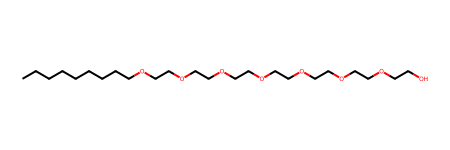

In [5]:
smi = input('Enter SMILES of your surfactant')
mol = Chem.MolFromSmiles(smi)


n_tertiary = len(mol.GetSubstructMatches(Chem.MolFromSmarts(tertiary)))
n_tertiary_2 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(tertiary_2)))
n_PO = len(mol.GetSubstructMatches(Chem.MolFromSmarts(PO)))
n_EO = len(mol.GetSubstructMatches(Chem.MolFromSmarts(EO)))
n_p1 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(p1)))
n_p2 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(p2)))

n_secondary = len(mol.GetSubstructMatches(Chem.MolFromSmarts(secondary)))
n_benzene = len(mol.GetSubstructMatches(Chem.MolFromSmarts(benzene)))
n_tertiary_non_2 = n_tertiary-n_tertiary_2-n_PO

number_of_carbons = (n_p1 + n_p2 +n_secondary)+6.9*n_tertiary_2 + 0.71 * n_tertiary_non_2 +3.5 * n_benzene
Lc = 1.5 + 1.265 * number_of_carbons
L = 1.3 * Lc
MWt = MolWt(mol)
print('Molecular weiight of the molecule is {}'.format(MWt))
print('Tail length is {}'.format(L))
mol

In [7]:
surfactant_selection = widgets.Dropdown(options = ['', 'Ionic', 'Nonionic'], value = '')
surfactant_selection

Dropdown(options=('', 'Ionic', 'Nonionic'), value='')

Enter concentrations

In [9]:
wt_concentrations_range = (float(input('Enter lower concentration calue value of surfactant')), 
                float(input('Enter upperlower concentration calue value of surfactant ')))

wt_concentrations = np.linspace(wt_concentrations_range[0], wt_concentrations_range[1], 100)
C_mol_range = ((1000 * wt_concentrations / 100)/MWt)/1000

Enter lower concentration calue value of surfactant 1
Enter upperlower concentration calue value of surfactant  5


Calculate xi here 

In [17]:
MWt_oil = float(input('Molecular weight of the oil'))
density = float(input('Density of the oil, g/cc'))
interfacial_area = float(input(r'Interfacial area Å2'))
xi = xi_calculation(L, interfacial_area, density, MWt_oil, surfactant_type=surfactant_selection.value)
print('Automatically calculated ξ is {}'.format(xi))

Molecular weight of the oil 104
Density of the oil, g/cc 0.76
Interfacial area Å2 45


Automatically calculated ξ is 984508.2185474382


Or enter  your own value

In [19]:
xi = float(input('Your manual value of ξ'))
interfacial_area = float(input(r'Interfacial area Å2'))

Your manual value of ξ 153
Interfacial area Å2 45


Enter volumes of water and oil

In [21]:
Vw = (float(input('Enter volume of water, mL ')))
Vo = (float(input('Enter volume of oil, mL ')))


As = {C: Vw*C*6E23*interfacial_area/1E24 for C in C_mol_range}
Rw_ref_range = {C:3*Vw/As[C] for C in C_mol_range}
Ro_ref_range = {C:3*Vo/As[C] for C in C_mol_range}

Enter volume of water, mL  10
Enter volume of oil, mL  10


**Enter HLD parameters**

In [18]:
variable_selection = widgets.Dropdown(options = ['', 'Cc', 'EACN', 'Salinity', 'Temperature'], value = '')
variable_selection

Dropdown(options=('', 'Cc', 'EACN', 'Salinity', 'Temperature'), value='')

In [20]:
varied_value = (float(input('Enter first range value of {}'.format(variable_selection.value))), 
                float(input('Enter end range value of {}'.format(variable_selection.value))))
varied_value_range = np.linspace(varied_value[0], varied_value[1], 100)

Enter first range value of Temperature 25
Enter end range value of Temperature 70


In [22]:
if variable_selection.value == 'EACN':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Cc':
    EACN = float(input('Enter EACN value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Temperature':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    EACN = float(input('Enter EACN value'))
elif variable_selection.value == 'Salinity':
    Cc = float(input('Enter Cc value'))
    Temp = float(input('Enter temperature'))
    EACN = float(input('Enter EACN value'))

Enter Cc value -1
Enter salinity value 2
Enter EACN value 8


In [24]:
if variable_selection.value == 'EACN':
    HLDs = HLD_calculation(EACN = varied_value_range, Cc = Cc, Sal = Sal, Temp = Temp, Type = surfactant_selection.value)
elif variable_selection.value == 'Cc':
    HLDs = HLD_calculation(EACN = EACN, Cc = varied_value_range, Sal = Sal, Temp = Temp, Type = surfactant_selection.value)
elif variable_selection.value == 'Temperature':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = Sal, Temp = varied_value_range, Type = surfactant_selection.value)
elif variable_selection.value == 'Salinity':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = varied_value_range, Temp = Temp, Type = surfactant_selection.value)

**Plot the phase diagram**

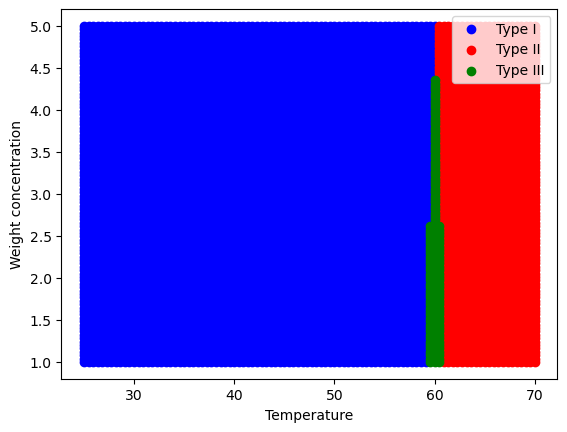

In [26]:
Hs = -(HLDs/L)
Ros = np.zeros((len(Hs), len(C_mol_range)), dtype = 'float')
Rws = np.zeros((len(Hs), len(C_mol_range)), dtype = 'float')

for (i, C), (j, H) in product(enumerate(C_mol_range), enumerate(Hs)):
    if H > 0:
        Rw = Rw_ref_range[C]
        Ro = 1/(H+1/Rw)
        Ros[i,j] = Ro
        Rws[i,j] = Rw
    else:
        Ro = Ro_ref_range[C]
        Rw = 1/(np.abs(H)+1/Ro)
        Ros[i,j] = Ro
        Rws[i,j] = Rw

NACs = 0.5*((1/Ros)+(1/Rws))
NACs_bin = Ros > Rws
NACs_bins  = (Ros > Rws).astype(int)
mask = (NACs<1/xi)
NACs_bins[mask] = 2
HH, CC = np.meshgrid(varied_value_range, wt_concentrations)


fig, ax = plt.subplots()
NACs_bins_fl = NACs_bins.flatten()
color = {0:'blue', 1:'red', 2:'green'}
labels = {0:'Type I', 1:'Type II', 2:'Type III'}


for val in (0,1,2):
    mask = (NACs_bins_fl==val)
    scatter = ax.scatter(x = HH.flatten()[mask], y = CC.flatten()[mask], c = color[val], label = labels[val])
#scatter = ax.scatter(HH.flatten(), CC.flatten(), c = NACs_bins)
#scatter = ax.scatter(HH.flatten(), CC.flatten(), c = NACs_bins)


ax.set_xlabel(variable_selection.value)
ax.set_ylabel('Weight concentration')

ax.legend()